<a href="https://colab.research.google.com/github/duembi/Graphical-Machine-Learning/blob/main/01_from_svd_to_similarity_gcn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Machine Learning: From (SVD) To (GCN)

Bu notebook, çizge (graph) verileri üzerinde makine öğrenmesi uygulamalarını adım adım koda dökmektedir. Geleneksel lineer cebir yöntemlerinden (SVD, Katz Difüzyonu) başlayarak, güncel **Similarity-Based Graph Convolutional Networks (Benzerlik Tabanlı GCN)** mimarisine kadar uzanan bir yolculuk yapacağız.

Kullanılan veri seti, literatürün en ünlü oyuncak veri setlerinden olan **Zachary's Karate Club** ağıdır.

In [ ]:
import numpy as np
import networkx as nx
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Rastgelelik tohumlarını sabitleyelim (Tekrarlanabilirlik için)
np.random.seed(42)
torch.manual_seed(42)

## 1. Çizgeyi Oluşturma ve Temel Matrisler
Öncelikle ağımızı oluşturup temel matrisleri ($A$ ve $D$) çekiyoruz.
* **Komşuluk Matrisi ($A$):** Düğümler arası fiziksel bağlantıları tutar.
* **Derece Matrisi ($D$):** Köşegenlerinde her düğümün komşu sayısını tutar.

In [ ]:
G = nx.karate_club_graph()
N = G.number_of_nodes()

A = nx.to_numpy_array(G)
D = np.diag([deg for _, deg in G.degree()])

print(f"Grafik {N} düğümden ve {G.number_of_edges()} kenardan oluşuyor.")

Grafik 34 düğümden ve 78 kenardan oluşuyor.


## 2. Sığ Kodlama (Shallow Embedding) ve SVD
Ham $A$ matrisi yerine, geçiş olasılıklarını ifade eden Normalize Geçiş Matrisini ($P$) kullanırız:
$$P = D^{-1}A$$

Bu matrisin boyutunu düşürmek ve her düğümü $d=16$ boyutlu bir uzaya gömmek için **Tekil Değer Ayrışımı (SVD)** uygularız. Optimizasyon hedefimiz şudur:
$$\min_U || P - U U^T ||_F^2$$

In [ ]:
# P Matrisinin Hesaplanması
D_inv = np.linalg.inv(D)
P = np.dot(D_inv, A)

# SVD İşlemi
U, Sigma, Vt = np.linalg.svd(P)

# İlk d bileşeni alarak boyut düşürme
d = 16
node_embeddings_svd = U[:, :d] * np.sqrt(Sigma[:d])

print(f"SVD ile elde edilen Embedding Matrisi: {node_embeddings_svd.shape}")

SVD ile elde edilen Embedding Matrisi: (34, 16)


## 3. Derin Kodlama (Deep Embedding) ve Hub-Promoted Index (HPI)
Sadece 1. derece komşuları değil, anlamsal (semantik) yapıları da öğrenmek için *Mustafa Coşkun* hocanın makalelerinde geçen **Hub-Promoted Index** gibi benzerlik metriklerini kullanabiliriz. Aralarında fiziksel bir kenar olmasa bile, aynı ortak komşulara sahip düğümler birbirine yapısal olarak benzerdir.

Benzerlik matrisimizi ($S$) hesaplayıp, bunu tek katmanlı bir **Graph Convolutional Network (GCN)** içine yerleştireceğiz:
$$H^{(1)} = \sigma(S X W)$$

In [ ]:
# HPI Benzerlik Matrisinin Hesaplanması
S = np.zeros((N, N))
for u in range(N):
    for v in range(N):
        if u != v:
            neighbors_u = set(G.neighbors(u))
            neighbors_v = set(G.neighbors(v))
            common_neighbors = len(neighbors_u.intersection(neighbors_v))

            min_degree = min(G.degree(u), G.degree(v))
            if min_degree > 0:
                S[u, v] = common_neighbors / min_degree

np.fill_diagonal(S, 1.0) # Kendine dönüşler (Self-loops)

# PyTorch ile GCN Katmanı
class SimilarityGCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(SimilarityGCNLayer, self).__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)
        self.activation = nn.ReLU()

    def forward(self, S_matrix, X_features):
        support = self.W(X_features)
        output = torch.matmul(S_matrix, support)
        return self.activation(output)

S_tensor = torch.FloatTensor(S)
X_tensor = torch.eye(N) # Özellik matrisi (Şimdilik one-hot)

gcn_layer = SimilarityGCNLayer(in_features=N, out_features=16)
node_embeddings_deep = gcn_layer(S_tensor, X_tensor)

print(f"Similarity-Based GCN Embedding Boyutu: {node_embeddings_deep.shape}")

Similarity-Based GCN Embedding Boyutu: torch.Size([34, 16])


## 4. Görselleştirme (Clustering / t-SNE)
Elde ettiğimiz 16 boyutlu GCN embedding'lerini **t-SNE** kullanarak 2 boyuta düşürüyoruz. Karate Club ağındaki düğümlerin gerçek etiketlerini (Officer vs. Mr. Hi) renklendirerek, modelimizin benzer düğümleri uzayda nasıl aynı kümeye (cluster) koyduğunu gözlemleyelim.

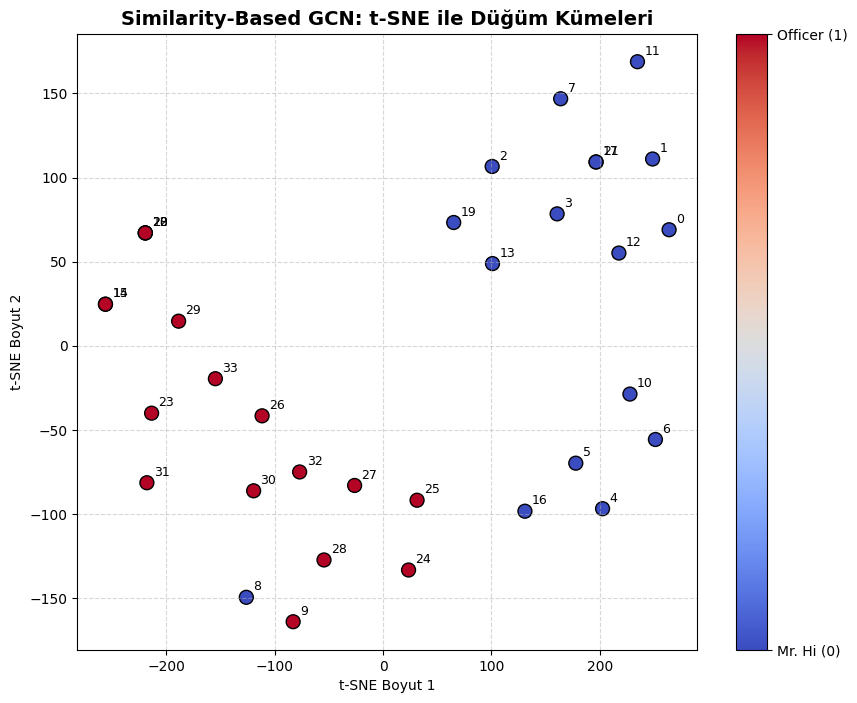

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ==========================================
# ADIM 6: Boyut Düşürme ve Görselleştirme (t-SNE)
# ==========================================
def plot_embeddings(embeddings_tensor, graph, title="GCN Embedding t-SNE Görselleştirmesi"):
    # 1. PyTorch tensorünü NumPy dizisine çevir
    # (Eğer modelin gradient'leri varsa önce detach() etmemiz gerekir)
    embeddings_np = embeddings_tensor.detach().numpy()

    # 2. 16 boyutu 2 boyuta düşür (t-SNE)
    # Karate Club (34 düğüm) gibi küçük veri setlerinde perplexity değerini düşük tutarız
    tsne = TSNE(n_components=2, perplexity=10, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings_np)

    # 3. Düğümlerin gerçek sınıflarını (Officer vs Mr. Hi) çekelim
    # Bu sayede noktaları ait oldukları gruba göre renklendirebiliriz
    labels = [1 if graph.nodes[i]['club'] == 'Officer' else 0 for i in range(graph.number_of_nodes())]

    # 4. Matplotlib ile Çizim
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='coolwarm', s=100, edgecolors='k')

    # Noktaların yanına düğüm numaralarını yazalım ki kimin nerede olduğunu görelim
    for i in range(graph.number_of_nodes()):
        plt.annotate(str(i), (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("t-SNE Boyut 1")
    plt.ylabel("t-SNE Boyut 2")

    # Lejant (Renklerin anlamı) ekleyelim
    cbar = plt.colorbar(scatter, ticks=[0, 1])
    cbar.ax.set_yticklabels(['Mr. Hi (0)', 'Officer (1)'])

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Yazdığımız fonksiyonu, önceki adımdaki 'node_embeddings_deep' vektörleri ile çağıralım
plot_embeddings(node_embeddings_deep, G, title="Similarity-Based GCN: t-SNE ile Düğüm Kümeleri")